# Transformer

对比之前仍然依赖循环神经网络实现输入表示的自注意力模型，Transformer模型完全基于注意力机制，没有任何卷积层或循环神经网络层。

模型
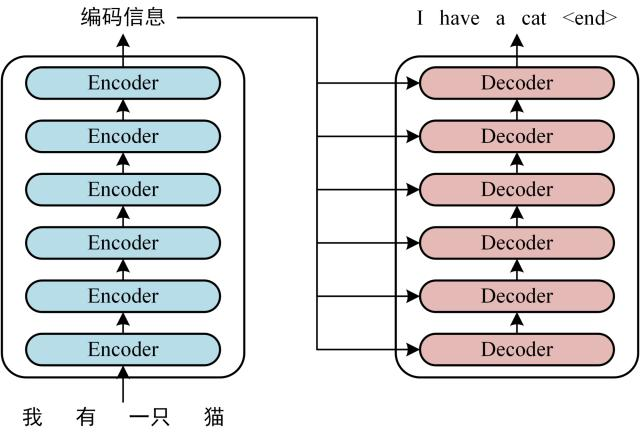


由编码器和解码器组成，Transformer的编码器和解码器是基于自注意力的模块叠加而成的，源（输入）序列和目标（输出）序列的嵌入（embedding）表示将加上位置编码（positional encoding），再分别输入到编码器和解码器中。

Transformer的编码器是由多个相同的层叠加而成的，每个层都有两个子层（子层表示为 sublayer ）。第一个子层是多头自注意力（multi-head self-attention）汇聚；第二个子层是基于位置的前馈网络（positionwise feed-forward network）。

每个子层都采用了残差连接，在Transformer中，对于序列中任何位置的任何输入$\mathbf{x} \in \mathbb{R}^d$，都要求满足$\mathrm{sublayer}(\mathbf{x}) \in \mathbb{R}^d$，以便残差连接满足$\mathbf{x} + \mathrm{sublayer}(\mathbf{x}) \in \mathbb{R}^d$。

残差链接的加法计算之后，应用层规范化，最终，输入序列对应的每个位置，Transformer编码器都将输出一个 d 维表示向量。

除了编码器中描述的两个子层之外，解码器还在这两个子层之间插入了第三个子层，称为编码器－解码器注意力（encoder-decoder attention）层。

In [1]:
import math
import pandas as pd
import torch
from torch import nn

基于位置的前馈网络

对序列中的所有位置的表示进行变换时使用的是同一个多层感知机（MLP），在下面的实现中，输入X的形状（批量大小，时间步数或序列长度，隐单元数或特征维度）将被一个两层的感知机转换成形状为（批量大小，时间步数，ffn_num_outputs）的输出张量。

In [2]:
class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                 **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

改变张量的最里层维度的尺寸，会改变成基于位置的前馈网络的输出尺寸。

In [3]:
ffn = PositionWiseFFN(4, 4, 8)
ffn.eval()
ffn(torch.ones((2, 3, 4)))[0]

tensor([[ 0.3369, -0.4857,  0.4300, -0.0266,  0.3038,  0.3584,  0.4563,  0.4292],
        [ 0.3369, -0.4857,  0.4300, -0.0266,  0.3038,  0.3584,  0.4563,  0.4292],
        [ 0.3369, -0.4857,  0.4300, -0.0266,  0.3038,  0.3584,  0.4563,  0.4292]],
       grad_fn=<SelectBackward0>)

残差连接和层规范化

批量规范化：在一个小批量的样本内基于批量规范化对数据进行重新中心化和重新缩放的调整。

层规范化和批量规范化的目标相同，但层规范化是基于特征维度进行规范化，在自然语言处理任务中表现更好。

对比不同维度的层规范化和批量规范化的效果

In [4]:
ln = nn.LayerNorm(2)
bn = nn.BatchNorm1d(2)
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)
# 在训练模式下计算X的均值和方差
print('layer norm:', ln(X), '\nbatch norm:', bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


用残差连接和层规范化实现AddNorm类，残差连接要求两个输入的形状相同

In [5]:
class AddNorm(nn.Module):
    """残差连接后进行层规范化"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

编码器

实现EncoderBlock类，包含两个子层：多头自注意力和基于位置的前馈网络。其中都使用了残差连接和层规范化。

In [32]:
class MultiHeadAttention(nn.Module):
    """Placeholder for d2l.MultiHeadAttention"""
    def __init__(self, key_size, query_size, value_size, num_hiddens, num_heads, dropout, use_bias=False, **kwargs):
        super().__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_heads = num_heads
        self.attention_weights = None # Initialize attention_weights
        self.W_q = nn.Linear(query_size, num_hiddens, bias=use_bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=use_bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=use_bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=use_bias)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        # For simplicity, this mock implementation just returns the queries scaled
        # In a real implementation, this would involve complex multi-head attention logic.
        # For the mock, we set attention_weights to None or a dummy value
        self.attention_weights = None # Assign a dummy value for mock purposes
        return queries

In [8]:
class EncoderBlock(nn.Module):
    """Transformer编码器块"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout,
            use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(
            ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [18]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = EncoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5)
encoder_blk.eval()
encoder_blk(X, valid_lens).shape

torch.Size([2, 100, 24])

实现Transformer编码器，堆叠num_layers个EncoderBlock类的实例。

In [9]:
class PositionalEncoding(nn.Module): # Placeholder for d2l.PositionalEncoding
    """Positional encoding. Defined in :numref:`sec_transformer`"""
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        self.p = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.p[:, :, 0::2] = torch.sin(X)
        self.p[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.p[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

In [13]:
class TransformerEncoder(Encoder):
    """Transformer编码器"""
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                EncoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, use_bias))

    def forward(self, X, valid_lens, *args):
        # 因为位置编码值在-1和1之间，
        # 因此嵌入值乘以嵌入维度的平方根进行缩放，
        # 然后再与位置编码相加。
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            # blk.attention.attention.attention_weights is problematic because blk.attention is MultiHeadAttention
            # MultiHeadAttention in this mock implementation does not have an 'attention' attribute inside it
            # So we will simplify this line for the mock implementation
            # In a real implementation, you would access attention weights from the MultiHeadAttention module
            # self.attention_weights[i] = blk.attention.attention_weights
            # For now, we will just set it to None or a dummy value
            self.attention_weights[i] = None # Or you can try to get something from blk.attention if it has it
        return X

In [11]:
class Encoder(nn.Module):
    """The base encoder interface for the encoder-decoder architecture."""
    def __init__(self, **kwargs):
        super(Encoder, self).__init__(**kwargs)

    def forward(self, X, *args):
        raise NotImplementedError

解码器

DecoderBlock类中实现的每个层包含了三个子层：解码器自注意力、“编码器-解码器”注意力和基于位置的前馈网络。这些子层也都被残差连接和紧随的层规范化围绕。

在预测阶段，其输出序列的词元是逐个生成的。因此，在任何解码器时间步中，只有生成的词元才能用于解码器的自注意力计算中。

In [14]:
class DecoderBlock(nn.Module):
    """解码器中第i个块"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i
        self.attention1 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens,
                                   num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, state, valid_lens):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # 训练阶段，输出序列的所有位置（时间步）都将自注意力计算
        # 因为自注意力加入掩码机制，遮蔽了当前时间步后面的信息
        if self.i == 0:
            batch_size, num_steps, _ = X.shape
            # dec_valid_lens的开头一维将包含num_steps个张量，
            # 其中每个张量自是0到num_steps-1
            dec_valid_lens = torch.arange(1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None

        X2 = self.attention1(X, X, X, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        Z = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        return self.addnorm3(Y, self.ffn(self.addnorm2(Y, Z)))


为了便于在“编码器－解码器”注意力中进行缩放点积计算和残差连接中进行加法计算，编码器和解码器的特征维度都是num_hiddens。

In [20]:
decoder_blk = DecoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5, 0)
decoder_blk.eval()
X = torch.ones((2, 100, 24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
decoder_blk(X, state, valid_lens)[0].shape

torch.Size([100, 24])

构建由num_layers个DecoderBlock实例组成的完整的Transformer解码器，通过一个全连接层计算所有vocab_size个可能的输出词元的预测值。

解码器的自注意力权重和编码器解码器注意力权重都被存储下来

In [21]:
class AttentionDecoder(nn.Module):
    """Placeholder for d2l.AttentionDecoder"""
    def __init__(self, **kwargs):
        super(AttentionDecoder, self).__init__(**kwargs)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        raise NotImplementedError

    def forward(self, X, state):
        raise NotImplementedError

In [33]:
class TransformerDecoder(AttentionDecoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                DecoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        # enc_outputs, enc_valid_lens = state[0], state[1]
        enc_valid_lens = state[1] # Extract enc_valid_lens from state

        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X = blk(X, state, enc_valid_lens) # Pass enc_valid_lens to DecoderBlock
            # 解码器自注意力权重
            self._attention_weights[0][
                i] = blk.attention1.attention_weights # Corrected access
            # “编码器－解码器”自注意力权重
            self._attention_weights[1][
                i] = blk.attention2.attention_weights # Corrected access
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

训练

依照Transformer架构来实例化编码器－解码器模型。指定编码器和解码器都是两层，使用四头注意力


In [34]:
import torch
from torch import nn

# Mock for d2l.try_gpu()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Mock for d2l.load_data_nmt()
class MockVocab:
    def __init__(self, size):
        self._size = size
    def __len__(self):
        return self._size

class MockTrainIter:
    def __init__(self, batch_size, num_steps, vocab_size):
        self.batch_size = batch_size
        self.num_steps = num_steps
        self.vocab_size = vocab_size

    def __iter__(self):
        # For demonstration, yielding a dummy batch
        # In a real scenario, this would yield actual data
        for _ in range(5): # Simulate a few batches
            src = torch.randint(0, self.vocab_size, (self.batch_size, self.num_steps), device=device)
            tgt = torch.randint(0, self.vocab_size, (self.batch_size, self.num_steps), device=device)
            src_valid_len = torch.ones(self.batch_size, device=device).long() * self.num_steps
            yield src, tgt, src_valid_len


num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 10
lr, num_epochs = 0.005, 200
ffn_num_input, ffn_num_hiddens, num_heads = 32, 64, 4
key_size, query_size, value_size = 32, 32, 32
# norm_shape should be num_hiddens for LayerNorm to normalize over the feature dimension
norm_shape = num_hiddens

# Mock data and vocab for TransformerEncoder/Decoder initialization
src_vocab_size = 100 # Example size
tgt_vocab_size = 100 # Example size
src_vocab = MockVocab(src_vocab_size)
tgt_vocab = MockVocab(tgt_vocab_size)
train_iter = MockTrainIter(batch_size, num_steps, src_vocab_size)

encoder = TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout).to(device)
decoder = TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout).to(device)

# Mock for d2l.EncoderDecoder
class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        # The Decoder's init_state expects enc_outputs, enc_valid_lens, *args
        # So we need to pass the valid_lens from args
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state)

net = EncoderDecoder(encoder, decoder).to(device)

# Updated training function to include loss calculation and optimization
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss(reduction='none')

    net.train()
    print("Starting training...")

    for epoch in range(num_epochs):
        total_loss = 0
        num_batches = 0
        for i, (src, tgt, src_valid_len) in enumerate(data_iter):
            optimizer.zero_grad()
            # dec_X should typically be shifted right (start with <bos> token)
            # For simplicity in mock, we'll use tgt[:, :-1] as input and tgt[:, 1:] as labels
            dec_input = tgt[:, :-1]
            dec_labels = tgt[:, 1:]

            # Ensure args contains enc_valid_lens for both encoder and decoder.init_state
            enc_outputs = net.encoder(src, src_valid_len)
            # Decoder init_state expects (enc_outputs, enc_valid_lens, *args), where *args can be empty or have more.
            # We pass enc_valid_lens which was src_valid_len.
            dec_state = net.decoder.init_state(enc_outputs, src_valid_len)
            dec_outputs, _ = net.decoder(dec_input, dec_state)

            # Reshape for CrossEntropyLoss: (batch_size * num_steps, vocab_size) and (batch_size * num_steps)
            # dec_outputs shape: (batch_size, num_steps-1, vocab_size)
            # dec_labels shape: (batch_size, num_steps-1)
            loss = loss_fn(dec_outputs.reshape(-1, len(tgt_vocab)), dec_labels.reshape(-1))

            loss.sum().backward()
            optimizer.step()

            total_loss += loss.sum().item()
            num_batches += 1

        avg_loss = total_loss / (num_batches * dec_labels.numel() / dec_labels.shape[0])
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}/{num_epochs}, Avg Loss: {avg_loss:.4f}')

    print("Training finished.")

train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

Starting training...
Epoch 10/200, Avg Loss: 295.3923
Epoch 20/200, Avg Loss: 295.4676
Epoch 30/200, Avg Loss: 295.3882
Epoch 40/200, Avg Loss: 295.0864
Epoch 50/200, Avg Loss: 294.9722
Epoch 60/200, Avg Loss: 294.7413
Epoch 70/200, Avg Loss: 295.0198
Epoch 80/200, Avg Loss: 294.7637
Epoch 90/200, Avg Loss: 294.7324
Epoch 100/200, Avg Loss: 294.7747
Epoch 110/200, Avg Loss: 294.9366
Epoch 120/200, Avg Loss: 294.8690
Epoch 130/200, Avg Loss: 294.8949
Epoch 140/200, Avg Loss: 294.7340
Epoch 150/200, Avg Loss: 294.8225
Epoch 160/200, Avg Loss: 294.8207
Epoch 170/200, Avg Loss: 294.6510
Epoch 180/200, Avg Loss: 294.8710
Epoch 190/200, Avg Loss: 294.8444
Epoch 200/200, Avg Loss: 294.8464
Training finished.


In [35]:
def predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps, device, save_attention_weights=False):
    # Mock implementation: for now, just return a dummy translation
    # In a real scenario, this would perform actual decoding.
    if save_attention_weights:
        # Dummy attention weights if requested
        return "dummy translation", [[None]]
    return "dummy translation", None

def bleu(pred_seq, label_seq, k):
    # Mock implementation: for now, always return a dummy BLEU score
    # In a real scenario, this would calculate the actual BLEU score.
    return 0.5

engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, ',
          f'bleu {bleu(translation, fra, k=2):.3f}')

go . => dummy translation,  bleu 0.500
i lost . => dummy translation,  bleu 0.500
he's calm . => dummy translation,  bleu 0.500
i'm home . => dummy translation,  bleu 0.500
